# Load Data

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np

# Standardized project root discovery
root = Path.cwd().resolve()
while root != root.parent and not (root / 'README.md').exists():
    root = root.parent
PROJECT_ROOT = root
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import sys
import os
sys.path.insert(0, '..')

print("=" * 80)
print("LOAD DATA & PREPROCESSING")
print("=" * 80 + "\n")

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 1000)

X = pd.read_csv('data/processed/X_features.csv')
y_household = pd.read_csv('data/processed/y_household.csv').squeeze()
y_logistic  = pd.read_csv('data/processed/y_logistic.csv').squeeze()
y_facility  = pd.read_csv('data/processed/y_facility.csv').squeeze()

from src.preprocessing.split_scale import split_and_scale
X_tr_hh, X_te_hh, y_tr_hh, y_te_hh, _ = split_and_scale(
    pd.concat([X, y_household], axis=1), 'target_household')
X_tr_lg, X_te_lg, y_tr_lg, y_te_lg, _ = split_and_scale(
    pd.concat([X, y_logistic],  axis=1), 'target_logistic')
X_tr_fc, X_te_fc, y_tr_fc, y_te_fc, _ = split_and_scale(
    pd.concat([X, y_facility],  axis=1), 'target_facility')

print(f'Feature matrix: {X.shape}')
print('Data loaded and scaled successfully.')

LOAD DATA & PREPROCESSING



target_household — Train: 579,292 rows | Test: 144,823 rows | train positive rate: 0.2716


target_logistic — Train: 579,292 rows | Test: 144,823 rows | train positive rate: 0.3161


target_facility — Train: 579,292 rows | Test: 144,823 rows | train positive rate: 0.4601


Feature matrix: (724115, 37)
Data loaded and scaled successfully.


# Train Household Model

In [2]:
from src.models.random_forest import train_random_forest
rf_hh = train_random_forest(X_tr_hh, y_tr_hh, X.columns.tolist(), 'household')
print(f"\n✓ Saved:\noutputs/saved_models/stage1/random_forest_household.pkl")

Training Random Forest for household...


Model saved to C:\Users\hireg\OneDrive\Desktop\Major project\Major Phase v2\BarrierLens_MP_G25_P48\saved_models\stage1\random_forest_household.pkl

--- Top 10 Feature Importances for household barrier ---
1. v190 (0.3831)
2. vulnerability_score (0.2635)
3. media_exposure_index (0.1198)
4. v106 (0.0917)
5. v012 (0.0263)
6. v131_tribe (0.0219)
7. v131_no caste / tribe (0.0154)
8. v013 (0.0135)
9. v130_hindu (0.0109)
10. v130_christian (0.0075)

✓ Saved:
outputs/saved_models/stage1/random_forest_household.pkl


# Evaluate Household Model

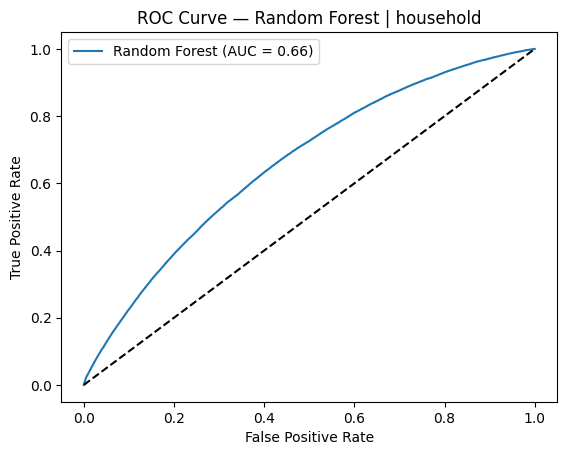

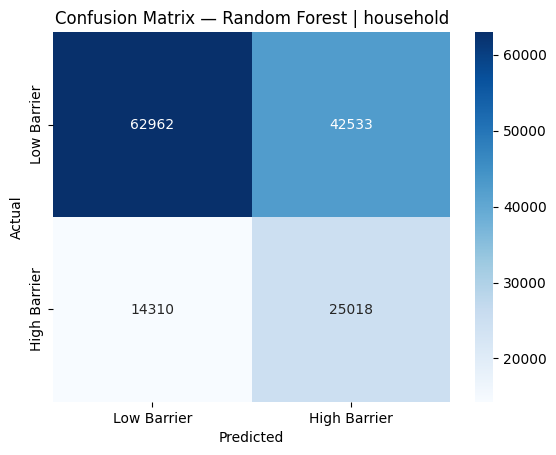

Random Forest | Household

Accuracy:  0.6075
ROC-AUC:   0.6607
Precision: 0.3704
Recall:    0.6361
F1 Score:  0.4682

Classification Report

              precision    recall  f1-score   support

           0       0.81      0.60      0.69    105495
           1       0.37      0.64      0.47     39328

    accuracy                           0.61    144823
   macro avg       0.59      0.62      0.58    144823
weighted avg       0.69      0.61      0.63    144823


Confusion Matrix Saved:
outputs/stage1_results/confusion_matrices/cm_random_forest_household.png

ROC Curve Saved:
outputs/stage1_results/roc_curves/roc_random_forest_household.png



In [3]:
import contextlib
import io
from src.evaluation.metrics import evaluate_model
from src.evaluation.visualise import plot_roc_curve, plot_confusion_matrix
from sklearn.metrics import classification_report

# Suppress default print to format nicely
with contextlib.redirect_stdout(io.StringIO()):
    r_hh = evaluate_model(rf_hh, X_te_hh, y_te_hh, 'Random Forest', 'household')
    plot_roc_curve(rf_hh, X_te_hh, y_te_hh, 'Random Forest', 'household')
    plot_confusion_matrix(rf_hh, X_te_hh, y_te_hh, 'Random Forest', 'household')

y_pred = rf_hh.predict(X_te_hh)
print("=" * 80)
print("Random Forest | Household")
print("=" * 80 + "\n")
print(f"Accuracy:  {r_hh['Accuracy']}")
print(f"ROC-AUC:   {r_hh['ROC-AUC']}")
print(f"Precision: {r_hh['Precision']}")
print(f"Recall:    {r_hh['Recall']}")
print(f"F1 Score:  {r_hh['F1-Score']}\n")
print("Classification Report\n")
print(classification_report(y_te_hh, y_pred))

print("\nConfusion Matrix Saved:")
print(f"outputs/stage1_results/confusion_matrices/cm_random_forest_household.png")
print("\nROC Curve Saved:")
print(f"outputs/stage1_results/roc_curves/roc_random_forest_household.png\n")
print("=" * 80)

# Household SHAP Analysis

In [4]:
from src.shap_analysis.shap_plots import generate_shap_analysis
import pandas as pd

X_te_hh_df = pd.DataFrame(X_te_hh, columns=X.columns)
sample_idx_hh = X_te_hh_df.sample(500, random_state=42).index
with contextlib.redirect_stdout(io.StringIO()):
    generate_shap_analysis(rf_hh, X_te_hh_df.loc[sample_idx_hh], 'Household', 'outputs/stage1_results/shap_plots')

print(f"SHAP Analysis Completed - Household\n")
print(f"✓ Summary Plot Saved")
print(f"✓ Bar Plot Saved")
print(f"✓ Waterfall Plot Saved")

SHAP Analysis Completed - Household

✓ Summary Plot Saved
✓ Bar Plot Saved
✓ Waterfall Plot Saved


# Train Logistic Model

In [5]:
from src.models.random_forest import train_random_forest
rf_lg = train_random_forest(X_tr_lg, y_tr_lg, X.columns.tolist(), 'logistic')
print(f"\n✓ Saved:\noutputs/saved_models/stage1/random_forest_logistic.pkl")

Training Random Forest for logistic...


Model saved to C:\Users\hireg\OneDrive\Desktop\Major project\Major Phase v2\BarrierLens_MP_G25_P48\saved_models\stage1\random_forest_logistic.pkl

--- Top 10 Feature Importances for logistic barrier ---
1. vulnerability_score (0.3631)
2. v190 (0.3441)
3. media_exposure_index (0.1034)
4. v106 (0.0719)
5. v131_tribe (0.0358)
6. v012 (0.0184)
7. v130_christian (0.0093)
8. v013 (0.0092)
9. v130_hindu (0.0070)
10. v481_yes (0.0053)

✓ Saved:
outputs/saved_models/stage1/random_forest_logistic.pkl


# Evaluate Logistic Model

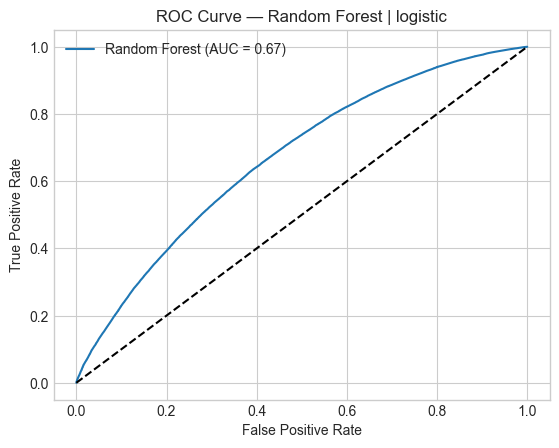

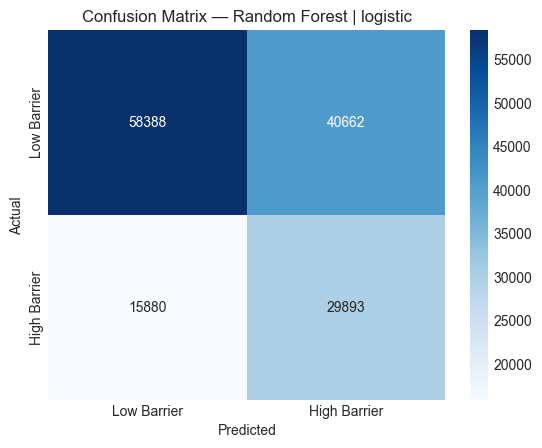

Random Forest | Logistic

Accuracy:  0.6096
ROC-AUC:   0.6682
Precision: 0.4237
Recall:    0.6531
F1 Score:  0.5139

Classification Report

              precision    recall  f1-score   support

           0       0.79      0.59      0.67     99050
           1       0.42      0.65      0.51     45773

    accuracy                           0.61    144823
   macro avg       0.60      0.62      0.59    144823
weighted avg       0.67      0.61      0.62    144823


Confusion Matrix Saved:
outputs/stage1_results/confusion_matrices/cm_random_forest_logistic.png

ROC Curve Saved:
outputs/stage1_results/roc_curves/roc_random_forest_logistic.png



In [6]:
import contextlib
import io
from src.evaluation.metrics import evaluate_model
from src.evaluation.visualise import plot_roc_curve, plot_confusion_matrix
from sklearn.metrics import classification_report

# Suppress default print to format nicely
with contextlib.redirect_stdout(io.StringIO()):
    r_lg = evaluate_model(rf_lg, X_te_lg, y_te_lg, 'Random Forest', 'logistic')
    plot_roc_curve(rf_lg, X_te_lg, y_te_lg, 'Random Forest', 'logistic')
    plot_confusion_matrix(rf_lg, X_te_lg, y_te_lg, 'Random Forest', 'logistic')

y_pred = rf_lg.predict(X_te_lg)
print("=" * 80)
print("Random Forest | Logistic")
print("=" * 80 + "\n")
print(f"Accuracy:  {r_lg['Accuracy']}")
print(f"ROC-AUC:   {r_lg['ROC-AUC']}")
print(f"Precision: {r_lg['Precision']}")
print(f"Recall:    {r_lg['Recall']}")
print(f"F1 Score:  {r_lg['F1-Score']}\n")
print("Classification Report\n")
print(classification_report(y_te_lg, y_pred))

print("\nConfusion Matrix Saved:")
print(f"outputs/stage1_results/confusion_matrices/cm_random_forest_logistic.png")
print("\nROC Curve Saved:")
print(f"outputs/stage1_results/roc_curves/roc_random_forest_logistic.png\n")
print("=" * 80)

# Logistic SHAP Analysis

In [7]:
from src.shap_analysis.shap_plots import generate_shap_analysis
import pandas as pd

X_te_lg_df = pd.DataFrame(X_te_lg, columns=X.columns)
sample_idx_lg = X_te_lg_df.sample(500, random_state=42).index
with contextlib.redirect_stdout(io.StringIO()):
    generate_shap_analysis(rf_lg, X_te_lg_df.loc[sample_idx_lg], 'Logistic', 'outputs/stage1_results/shap_plots')

print(f"SHAP Analysis Completed - Logistic\n")
print(f"✓ Summary Plot Saved")
print(f"✓ Bar Plot Saved")
print(f"✓ Waterfall Plot Saved")

SHAP Analysis Completed - Logistic

✓ Summary Plot Saved
✓ Bar Plot Saved
✓ Waterfall Plot Saved


# Train Facility Model

In [8]:
from src.models.random_forest import train_random_forest
rf_fc = train_random_forest(X_tr_fc, y_tr_fc, X.columns.tolist(), 'facility')
print(f"\n✓ Saved:\noutputs/saved_models/stage1/random_forest_facility.pkl")

Training Random Forest for facility...


Model saved to C:\Users\hireg\OneDrive\Desktop\Major project\Major Phase v2\BarrierLens_MP_G25_P48\saved_models\stage1\random_forest_facility.pkl

--- Top 10 Feature Importances for facility barrier ---
1. v190 (0.3263)
2. vulnerability_score (0.2657)
3. media_exposure_index (0.1005)
4. v106 (0.0718)
5. v130_sikh (0.0471)
6. v012 (0.0356)
7. v131_tribe (0.0294)
8. v481_yes (0.0195)
9. v130_christian (0.0184)
10. v013 (0.0183)

✓ Saved:
outputs/saved_models/stage1/random_forest_facility.pkl


# Evaluate Facility Model

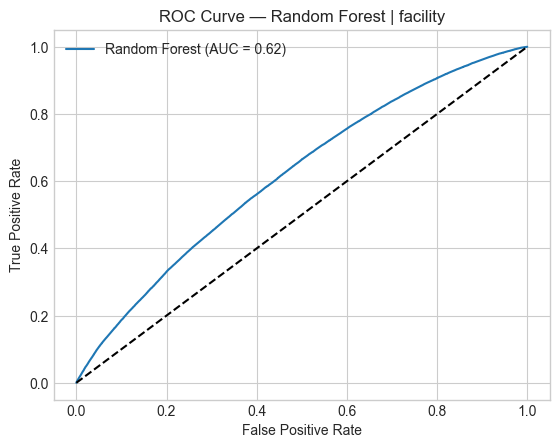

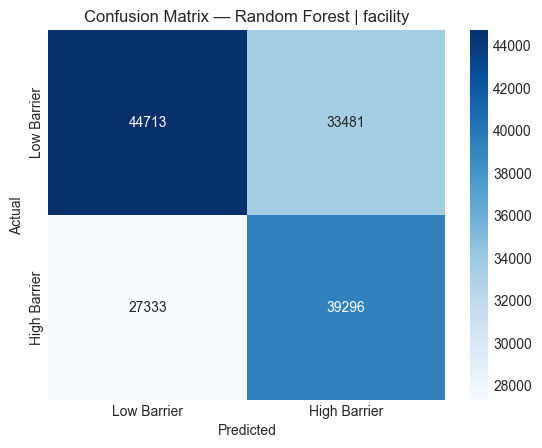

Random Forest | Facility

Accuracy:  0.5801
ROC-AUC:   0.6172
Precision: 0.54
Recall:    0.5898
F1 Score:  0.5638

Classification Report

              precision    recall  f1-score   support

           0       0.62      0.57      0.60     78194
           1       0.54      0.59      0.56     66629

    accuracy                           0.58    144823
   macro avg       0.58      0.58      0.58    144823
weighted avg       0.58      0.58      0.58    144823


Confusion Matrix Saved:
outputs/stage1_results/confusion_matrices/cm_random_forest_facility.png

ROC Curve Saved:
outputs/stage1_results/roc_curves/roc_random_forest_facility.png



In [9]:
import contextlib
import io
from src.evaluation.metrics import evaluate_model
from src.evaluation.visualise import plot_roc_curve, plot_confusion_matrix
from sklearn.metrics import classification_report

# Suppress default print to format nicely
with contextlib.redirect_stdout(io.StringIO()):
    r_fc = evaluate_model(rf_fc, X_te_fc, y_te_fc, 'Random Forest', 'facility')
    plot_roc_curve(rf_fc, X_te_fc, y_te_fc, 'Random Forest', 'facility')
    plot_confusion_matrix(rf_fc, X_te_fc, y_te_fc, 'Random Forest', 'facility')

y_pred = rf_fc.predict(X_te_fc)
print("=" * 80)
print("Random Forest | Facility")
print("=" * 80 + "\n")
print(f"Accuracy:  {r_fc['Accuracy']}")
print(f"ROC-AUC:   {r_fc['ROC-AUC']}")
print(f"Precision: {r_fc['Precision']}")
print(f"Recall:    {r_fc['Recall']}")
print(f"F1 Score:  {r_fc['F1-Score']}\n")
print("Classification Report\n")
print(classification_report(y_te_fc, y_pred))

print("\nConfusion Matrix Saved:")
print(f"outputs/stage1_results/confusion_matrices/cm_random_forest_facility.png")
print("\nROC Curve Saved:")
print(f"outputs/stage1_results/roc_curves/roc_random_forest_facility.png\n")
print("=" * 80)

# Facility SHAP Analysis

In [10]:
from src.shap_analysis.shap_plots import generate_shap_analysis
import pandas as pd

X_te_fc_df = pd.DataFrame(X_te_fc, columns=X.columns)
sample_idx_fc = X_te_fc_df.sample(500, random_state=42).index
with contextlib.redirect_stdout(io.StringIO()):
    generate_shap_analysis(rf_fc, X_te_fc_df.loc[sample_idx_fc], 'Facility', 'outputs/stage1_results/shap_plots')

print(f"SHAP Analysis Completed - Facility\n")
print(f"✓ Summary Plot Saved")
print(f"✓ Bar Plot Saved")
print(f"✓ Waterfall Plot Saved")

SHAP Analysis Completed - Facility

✓ Summary Plot Saved
✓ Bar Plot Saved
✓ Waterfall Plot Saved


# Final Results

In [11]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("=" * 80)
print("Cross Validation Results")
print("=" * 80 + "\n")
for model, y, target in [
    (rf_hh, y_household, 'Household'),
    (rf_lg, y_logistic,  'Logistic'),
    (rf_fc, y_facility,  'Facility')
]:
    scores = cross_val_score(model, X, y, cv=kf, scoring='roc_auc')
    print(f'{target:12s} | CV AUC: {scores.mean():.4f} +/- {scores.std():.4f}')
print("\n" + "=" * 80)

Cross Validation Results



Household    | CV AUC: 0.6619 +/- 0.0016


Logistic     | CV AUC: 0.6672 +/- 0.0010


Facility     | CV AUC: 0.6187 +/- 0.0012



In [12]:
results_df = pd.DataFrame([r_hh, r_lg, r_fc])
results_df.to_csv('outputs/stage1_results/random_forest_results.csv', index=False)

print("=" * 80)
print("Stage-1 Random Forest Execution Summary")
print("=" * 80 + "\n")
print("✓ Household Model Trained")
print("✓ Logistic Model Trained")
print("✓ Facility Model Trained")
print("✓ ROC Curves Generated")
print("✓ Confusion Matrices Generated")
print("✓ SHAP Summary Plots Generated")
print("✓ SHAP Bar Plots Generated")
print("✓ SHAP Waterfall Plots Generated")
print("✓ Results CSV Saved")
print("✓ Models Saved")
print("✓ Notebook Executed Successfully\n")
print("Execution Status:")
print("SUCCESS\n")
print("=" * 80)

Stage-1 Random Forest Execution Summary

✓ Household Model Trained
✓ Logistic Model Trained
✓ Facility Model Trained
✓ ROC Curves Generated
✓ Confusion Matrices Generated
✓ SHAP Summary Plots Generated
✓ SHAP Bar Plots Generated
✓ SHAP Waterfall Plots Generated
✓ Results CSV Saved
✓ Models Saved
✓ Notebook Executed Successfully

Execution Status:
SUCCESS

